# 03 — Exploratory Analysis

Volcano plot, sample clustering, and protein distribution exploration.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import *
from src.data_extraction import load_all_data
from src.preprocessing import preprocess_expression_matrix
from src.figures import set_publication_style, plot_volcano
set_publication_style()

In [2]:
data = load_all_data()
sig = data['sig_proteins']
matrix = preprocess_expression_matrix(data['mouse_matrix'])

[data_extraction] Loading real data from aba6334_data_file_s1.xlsx and aba6334_data_file_s3.xlsx


/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/data_extraction.py:94: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({"undetected": np.nan, "NaN": np.nan, "nan": np.nan})
/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/data_extraction.py:94: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({"undetected": np.nan, "NaN": np.nan, "nan": np.nan})
/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/d

  Proteins:      1505
  Significant:   71
  Mouse samples: 11
  Human subjects:58
  Data source:   supplement


In [3]:
# Volcano plot
plot_volcano(sig)
print('Volcano plot saved to figures/')

/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/figures.py:73: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/figures.py:73: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
/Users/mohamedsmacbookair/Programs/Research/edosomal-biomarker-ml/notebooks/../src/figures.py:73: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")


[figures] Saved fig1_volcano
Volcano plot saved to figures/


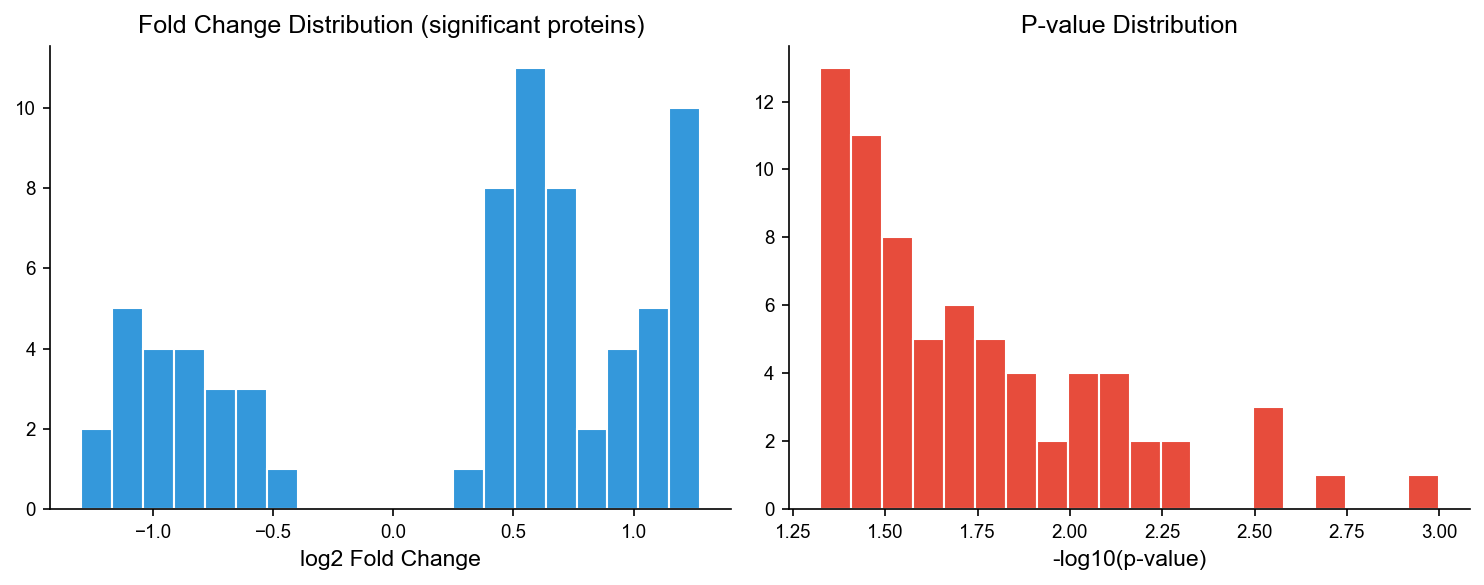

In [4]:
# Distribution of fold changes
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(sig['log2_fc'], bins=20, color='#3498db', edgecolor='white')
axes[0].set_xlabel('log2 Fold Change')
axes[0].set_title('Fold Change Distribution (significant proteins)')
axes[1].hist(-np.log10(sig['pvalue'].clip(1e-10)), bins=20, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('-log10(p-value)')
axes[1].set_title('P-value Distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_eda_distributions.png', dpi=150)
plt.show()

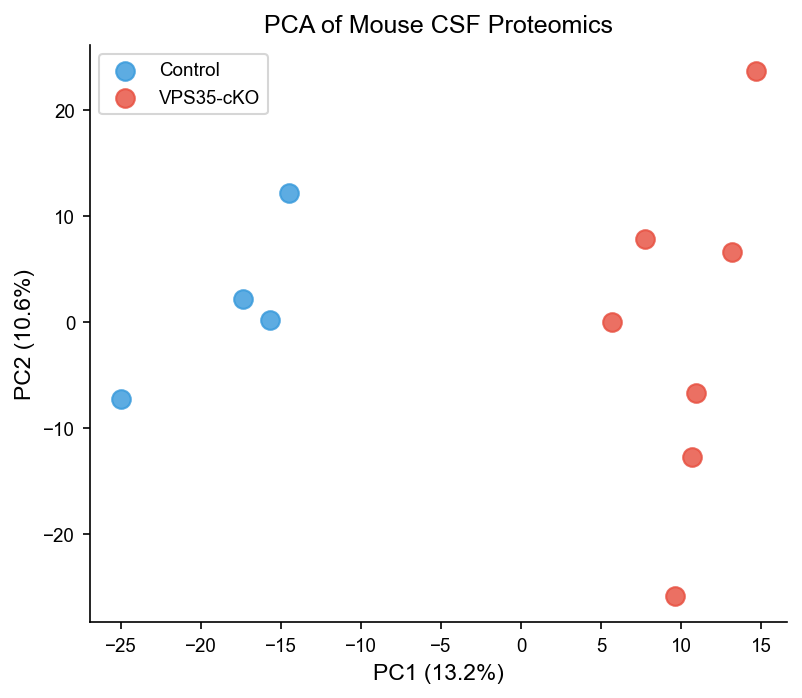

In [5]:
# Sample PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
prot = matrix.drop(columns=['label'])
X_sc = StandardScaler().fit_transform(prot.values)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_sc)
labels_arr = matrix['label'].values
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, color, name in [(0, '#3498db', 'Control'), (1, '#e74c3c', 'VPS35-cKO')]:
    mask = labels_arr == lbl
    ax.scatter(coords[mask, 0], coords[mask, 1], label=name, color=color, s=80, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Mouse CSF Proteomics')
ax.legend()
plt.savefig(FIGURES_DIR / 'fig_eda_pca.png', dpi=150)
plt.show()

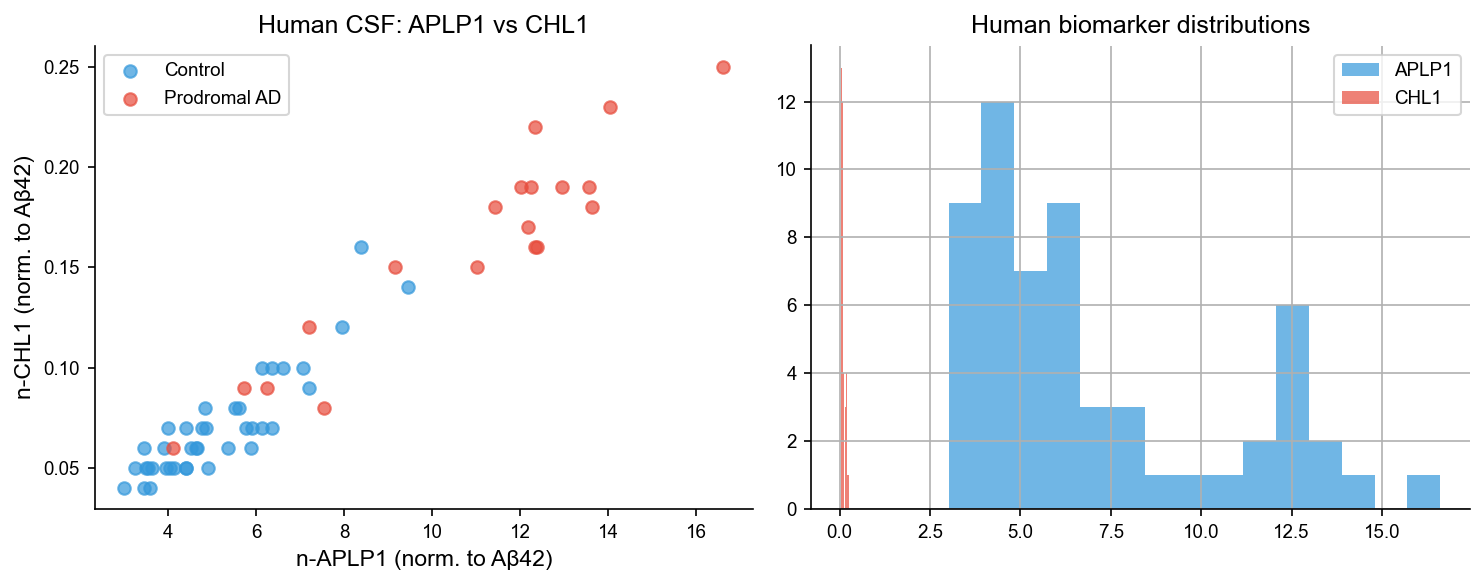

In [6]:
# Human data exploration
human = data['human_clinical']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for lbl, color, name in [(0, '#3498db', 'Control'), (1, '#e74c3c', 'Prodromal AD')]:
    sub = human[human['label'] == lbl]
    axes[0].scatter(sub['n_APLP1'], sub['n_CHL1'], color=color, label=name, alpha=0.7)
axes[0].set_xlabel('n-APLP1 (norm. to Aβ42)')
axes[0].set_ylabel('n-CHL1 (norm. to Aβ42)')
axes[0].set_title('Human CSF: APLP1 vs CHL1')
axes[0].legend()
human['n_APLP1'].hist(bins=15, ax=axes[1], color='#3498db', alpha=0.7, label='APLP1')
human['n_CHL1'].hist(bins=15, ax=axes[1], color='#e74c3c', alpha=0.7, label='CHL1')
axes[1].set_title('Human biomarker distributions')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_eda_human.png', dpi=150)
plt.show()